Best parameters found:  {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.7}

In [13]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [14]:
df = pd.read_csv("Ready_Data.csv")
df.head()

,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumHeteroatoms,MolLogP,NumRings,...,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047,Molecular Weight,label
0,1,4,58.64,0,1,2,4,5,4.8690,5,...,0,0,0,0,0,0,0,0,412.57,1
1,0,2,23.06,5,3,0,0,4,5.5489,3,...,0,0,0,0,0,0,0,0,391.36,0
2,1,3,30.49,5,1,1,1,3,2.9465,2,...,0,0,0,0,0,0,0,0,263.38,0
3,0,2,12.47,4,1,1,1,2,3.2801,2,...,0,0,0,0,0,0,0,0,247.38,0
4,1,3,32.70,7,1,1,1,3,4.1560,2,...,0,0,0,0,0,0,0,0,305.46,0


In [15]:
x = df.drop(["label"], axis=1)
y = df["label"]

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=42)

In [17]:
model = XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=42, colsample_bytree= 1.0, learning_rate= 0.1, max_depth= 5, n_estimators= 500, subsample= 0.7)

In [18]:
model.fit(x_train, y_train)

f:\gla\Machine_Learning\MiniProject\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [03:41:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [19]:
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
train_accuracy = accuracy_score(y_train,y_train_pred)
test_accuracy = accuracy_score(y_test,y_test_pred)
print(f"Accuracy while training: {train_accuracy}")
print(f"Accuracy while testing: {test_accuracy}")

Accuracy while training: 0.9795390404515522
Accuracy while testing: 0.893796992481203


In [20]:
y_train_proba = model.predict_proba(x_train)[:, 1]
y_test_proba = model.predict_proba(x_test)[:, 1]

train_roc_auc = roc_auc_score(y_train,y_train_proba)
test_roc_auc = roc_auc_score(y_test,y_test_proba)
print("TRAINING PERFORMANCE:")
print(f"Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"ROC-AUC:  {train_roc_auc:.4f}")

print("\nTEST PERFORMANCE:")
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"ROC-AUC:  {test_roc_auc:.4f}")

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_test_pred, target_names=['Inactive', 'Active']))


TRAINING PERFORMANCE:
Accuracy: 0.9795 (97.95%)
ROC-AUC:  0.9979

TEST PERFORMANCE:
Accuracy: 0.8938 (89.38%)
ROC-AUC:  0.9322

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Inactive       0.76      0.65      0.70       205
      Active       0.92      0.95      0.94       859

    accuracy                           0.89      1064
   macro avg       0.84      0.80      0.82      1064
weighted avg       0.89      0.89      0.89      1064



In [21]:
cm = confusion_matrix(y_test,y_test_pred)
print(f"Confusion Metrix:\n{cm}")

Confusion Metrix:
[[133  72]
 [ 41 818]]


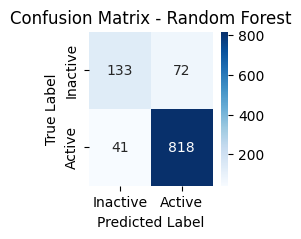

In [22]:
plt.figure(figsize=(2, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Inactive', 'Active'],
            yticklabels=['Inactive', 'Active'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

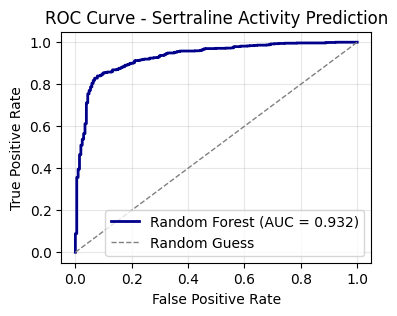

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'Random Forest (AUC = {test_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Sertraline Activity Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [24]:
with open("XGBoost_Model.pkl","wb") as m:
    pickle.dump(model,m)
with open("feature.pkl","wb") as f:
    pickle.dump(list(x.columns),f)